# Exploratory Data Analysis Cleaning and Flux Checks

**Goals**

1) Ensure data integrity
2) Remove missing or flagged data that may distort results

**Tasks**

1) Drop rows with NaN, NA, or zero-valued fluxes
2) Identify and quantify flux flags (e.g., saturation, deblending issues)
3) Pie chart: Ratio of clean vs flagged detections

In [42]:
# libraries, imports, etc
import numpy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns

print('numpy version: ', numpy.__version__)
print('matplotlib version: ', matplotlib.__version__)

numpy version:  2.2.6
matplotlib version:  3.10.3


In [43]:
# TAP Service 
from lsst.rsp import get_tap_service, retrieve_query
from pyvo.dal import TAPService
import lsst.daf.butler as dafButler
import lsst.geom
import lsst.afw.display as afwDisplay

service = get_tap_service("tap")
assert service is not None

In [44]:
# Selected Datasets

#1) DiaObject - core table for preprocessed time-varying object detections
diaobject_query = "SELECT column_name, datatype, description, unit "+\
                 "FROM TAP_SCHEMA.columns "+\
                 "WHERE table_name = 'dp1.DiaObject'"
diaobject_results = service.search(diaobject_query)
diaobject_results_table = diaobject_results.to_table().to_pandas()
print('Number of columns available in the DiaObject catalog: ', len(diaobject_results_table))

#2) DiaSource - individual photometric measurements (light curves) of variables
diasource_query = "SELECT column_name, datatype, description, unit "+\
                 "FROM TAP_SCHEMA.columns "+\
                 "WHERE table_name = 'dp1.DiaSource'"
diasource_results = service.search(diasource_query)
diasource_results_table = diasource_results.to_table().to_pandas()
print('Number of columns available in the DiaSource catalog: ', len(diasource_results_table))

#3) Object - static properties; mean position, reference band, color, etc
object_query = "SELECT column_name, datatype, description, unit "+\
                 "FROM TAP_SCHEMA.columns "+\
                 "WHERE table_name = 'dp1.Object'"
object_results = service.search(object_query)
object_results_table = object_results.to_table().to_pandas()
print('Number of columns available in the Object catalog: ', len(object_results_table))

Number of columns available in the DiaObject catalog:  137
Number of columns available in the DiaSource catalog:  87
Number of columns available in the Object catalog:  1296


In [45]:
# display table previews
diaobject_results_table

,column_name,datatype,description,unit
0,dec,double,Declination coordinate of the position of the ...,deg
1,diaObjectId,long,Unique identifier of this DiaObject.,
2,g_psfFluxChi2,float,Chi^2 statistic for the scatter of g_psfFlux a...,
3,g_psfFluxErrMean,float,Mean of the diaSource PSF flux errors,
4,g_psfFluxLinearIntercept,double,y-intercept of a linear model fit to diaSource...,
...,...,...,...,...
132,z_psfFluxSkew,float,Skew of diaSource PSF flux,
133,z_psfFluxStetsonJ,double,StetsonJ statistic of diaSource PSF flux,
134,z_scienceFluxMean,double,Weighted mean of the PSF flux forced photomete...,
135,z_scienceFluxMeanErr,double,Standard error on z_scienceFluxMean,


In [46]:
diasource_results_table

,column_name,datatype,description,unit
0,apFlux,float,Flux in a 12 pixel radius aperture on the diff...,nJy
1,apFlux_flag,boolean,General aperture flux algorithm failure flag; ...,
2,apFlux_flag_apertureTruncated,boolean,Aperture did not fit within measurement image.,
3,apFluxErr,float,Estimated uncertainty of apFlux.,nJy
4,band,char,Band used to take this observation.,
...,...,...,...,...
82,visit,long,Id of the visit where this diaSource was measu...,
83,x,double,"Unweighted first moment centroid, overall cent...",pixel
84,xErr,float,1-sigma uncertainty on x position,pixel
85,y,double,"Unweighted first moment centroid, overall cent...",pixel


In [47]:
object_results_table

,column_name,datatype,description,unit
0,coord_dec,double,Fiducial ICRS Declination of centroid used for...,deg
1,coord_decErr,float,Error in fiducial ICRS Declination of centroid,deg
2,coord_ra,double,Fiducial ICRS Right Ascension of centroid used...,deg
3,coord_ra_dec_Cov,float,Covariance between fiducial ICRS Right Ascensi...,deg**2
4,coord_raErr,float,Error in fiducial ICRS Right Ascension of cent...,deg
...,...,...,...,...
1291,z_raErr,float,"Error in right ascension, measured on z-band.",deg
1292,z_sersicFlux,float,z-band flux from the multiband Sersic model fit.,nJy
1293,z_sersicFluxErr,float,Error on the z-band flux from the multiband Se...,nJy
1294,z_sizeExtendedness,float,Moments-based measure of an object to be a gal...,


In [48]:
# Counts of observations in each dataset
# 1) DiaObject
diaobject_count_query = "SELECT COUNT(*) FROM dp1.DiaObject"
diaobject_count_result = service.search(diaobject_count_query)
print("Number of observations in DiaObject: ", diaobject_count_result.to_table()[0][0])

# 2) DiaSource
diasource_count_query = "SELECT COUNT(*) FROM dp1.DiaSource"
diasource_count_result = service.search(diasource_count_query)
print("Number of observations in DiaSource: ", diasource_count_result.to_table()[0][0])

# 3) Object
object_count_query = "SELECT COUNT(*) FROM dp1.Object"
object_count_result = service.search(object_count_query)
print("Number of observations in Object: ", object_count_result.to_table()[0][0])

Number of observations in DiaObject:  1089818
Number of observations in DiaSource:  3086404
Number of observations in Object:  2299757


In [62]:
# DiaObject g-band
job_dia_g = service.run_async("""
SELECT TOP 1000000
    diaObjectId, dec, ra, g_psfFluxErrMean, g_psfFluxLinearSlope,
    g_psfFluxMAD, g_psfFluxMax, g_psfFluxMean, g_psfFluxMeanErr,
    g_psfFluxMin, g_psfFluxNdata, g_psfFluxSigma, g_psfFluxStetsonJ
FROM dp1.DiaObject
""")
diaobjectG_df = job_dia_g.to_table().to_pandas()

# DiaObject r-band
job_dia_r = service.run_async("""
SELECT TOP 1000000
    diaObjectId, dec, ra, r_psfFluxErrMean, r_psfFluxLinearSlope,
    r_psfFluxMAD, r_psfFluxMax, r_psfFluxMean, r_psfFluxMeanErr,
    r_psfFluxMin, r_psfFluxNdata, r_psfFluxSigma, r_psfFluxStetsonJ
FROM dp1.DiaObject
""")
diaobjectR_df = job_dia_r.to_table().to_pandas()

# DiaObject i-band
job_dia_i = service.run_async("""
SELECT TOP 1000000
    diaObjectId, dec, ra, i_psfFluxErrMean, i_psfFluxLinearSlope,
    i_psfFluxMAD, i_psfFluxMax, i_psfFluxMean, i_psfFluxMeanErr,
    i_psfFluxMin, i_psfFluxNdata, i_psfFluxSigma, i_psfFluxStetsonJ
FROM dp1.DiaObject
""")
diaobjectI_df = job_dia_i.to_table().to_pandas()

# DiaObject all bands
job_dia_all = service.run_async("""
SELECT TOP 1000000
    diaObjectId, dec, ra, g_psfFluxErrMean, g_psfFluxLinearSlope,
    g_psfFluxMAD, g_psfFluxMax, g_psfFluxMean, g_psfFluxMeanErr,
    g_psfFluxMin, g_psfFluxNdata, g_psfFluxSigma, g_psfFluxStetsonJ,
    r_psfFluxErrMean, r_psfFluxLinearSlope,
    r_psfFluxMAD, r_psfFluxMax, r_psfFluxMean, r_psfFluxMeanErr,
    r_psfFluxMin, r_psfFluxNdata, r_psfFluxSigma, r_psfFluxStetsonJ,
    i_psfFluxErrMean, i_psfFluxLinearSlope,
    i_psfFluxMAD, i_psfFluxMax, i_psfFluxMean, i_psfFluxMeanErr,
    i_psfFluxMin, i_psfFluxNdata, i_psfFluxSigma, i_psfFluxStetsonJ
FROM dp1.DiaObject
""")
diaobject_df = job_dia_all.to_table().to_pandas()

# Object g-band
job_obj_g = service.run_async("""
SELECT TOP 1000000
    objectId, coord_ra, coord_dec, footprintArea, g_apFlux_flag, 
    g_apFlux_flag_apertureTruncated, g_bdChi2, g_bdFluxDErr, 
    g_calib_astrometry_used, g_calib_photometry_used, g_calibFlux_flag, 
    g_calibFlux_flag_apertureTruncated, g_cModel_flag, g_cModelFlux, g_dec, 
    g_extendedness, g_extendedness_flag, g_i_flag, g_inputCount, g_pixelFlags_bad, 
    g_psfFlux, g_psfFlux_flag, g_psfFluxErr, g_ra
FROM dp1.Object
""")
objectG_df = job_obj_g.to_table().to_pandas()

# Object r-band
job_obj_r = service.run_async("""
SELECT TOP 1000000
    objectId, coord_ra, coord_dec, footprintArea, r_apFlux_flag, 
    r_apFlux_flag_apertureTruncated, r_bdChi2, r_bdFluxDErr, 
    r_calib_astrometry_used, r_calib_photometry_used, r_calibFlux_flag, 
    r_calibFlux_flag_apertureTruncated, r_cModel_flag, r_cModelFlux, r_dec, 
    r_extendedness, r_extendedness_flag, r_i_flag, r_inputCount, r_pixelFlags_bad, 
    r_psfFlux, r_psfFlux_flag, r_psfFluxErr, r_ra
FROM dp1.Object
""")
objectR_df = job_obj_r.to_table().to_pandas()

# Object i-band
job_obj_i = service.run_async("""
SELECT TOP 1000000
    objectId, coord_ra, coord_dec, footprintArea, i_apFlux_flag, 
    i_apFlux_flag_apertureTruncated, i_bdChi2, i_bdFluxDErr, 
    i_calib_astrometry_used, i_calib_photometry_used, i_calibFlux_flag, 
    i_calibFlux_flag_apertureTruncated, i_cModel_flag, i_cModelFlux, i_dec, 
    i_extendedness, i_extendedness_flag, i_i_flag, i_inputCount, i_pixelFlags_bad, 
    i_psfFlux, i_psfFlux_flag, i_psfFluxErr, i_ra
FROM dp1.Object
""")
objectI_df = job_obj_i.to_table().to_pandas()

# Object all bands
job_obj_all = service.run_async("""
SELECT TOP 1000000
    objectId, coord_ra, coord_dec, footprintArea, g_apFlux_flag, 
    g_apFlux_flag_apertureTruncated, g_bdChi2, g_bdFluxDErr, 
    g_calib_astrometry_used, g_calib_photometry_used, g_calibFlux_flag, 
    g_calibFlux_flag_apertureTruncated, g_cModel_flag, g_cModelFlux, g_dec, 
    g_extendedness, g_extendedness_flag, g_i_flag, g_inputCount, g_pixelFlags_bad, 
    g_psfFlux, g_psfFlux_flag, g_psfFluxErr, g_ra,
    r_apFlux_flag, 
    r_apFlux_flag_apertureTruncated, r_bdChi2, r_bdFluxDErr, 
    r_calib_astrometry_used, r_calib_photometry_used, r_calibFlux_flag, 
    r_calibFlux_flag_apertureTruncated, r_cModel_flag, r_cModelFlux, r_dec, 
    r_extendedness, r_extendedness_flag, r_i_flag, r_inputCount, r_pixelFlags_bad, 
    r_psfFlux, r_psfFlux_flag, r_psfFluxErr, r_ra,
    i_apFlux_flag, 
    i_apFlux_flag_apertureTruncated, i_bdChi2, i_bdFluxDErr, 
    i_calib_astrometry_used, i_calib_photometry_used, i_calibFlux_flag, 
    i_calibFlux_flag_apertureTruncated, i_cModel_flag, i_cModelFlux, i_dec, 
    i_extendedness, i_extendedness_flag, i_i_flag, i_inputCount, i_pixelFlags_bad, 
    i_psfFlux, i_psfFlux_flag, i_psfFluxErr, i_ra
FROM dp1.Object
""")
object_df = job_obj_all.to_table().to_pandas()

# DiaSource
job_dia_source = service.run_async("""
SELECT TOP 1000000
    coord_dec, coord_ra, dec,
    diaObjectId, diaSourceId,
    forced_PsfFlux_flag, forced_PsfFlux_flag_edge, 
    forced_PsfFlux_flag_noGoodPixels, midPointMjdTai,
    psfFlux_flag, psfFlux_flag_edge, psfFlux_flag_noGoodPixels,
    psfFlux, psfFluxErr
FROM dp1.DiaSource
""")
diasource_df = job_dia_source.to_table().to_pandas()

In [63]:
# Creating csv files, run once!

# DiaObject (g, r, and i bands)
diaobjectG_df.to_csv("diaobjectG.csv", index=False)
diaobjectR_df.to_csv("diaobjectR.csv", index=False)
diaobjectI_df.to_csv("diaobjectI.csv", index=False)

# DiaSource
diasource_df.to_csv("diasource.csv", index=False)

# Object (g, r, and i bands)
objectG_df.to_csv("objectG.csv", index=False)
objectR_df.to_csv("objectR.csv", index=False)
objectI_df.to_csv("objectI.csv", index=False)

In [64]:
# Dropping rows and saving as cleaned csvs

# DiaObject dataframes (g, r, and i bands) 
diaobjectGdf = pd.read_csv("diaobjectG.csv").dropna()
diaobjectRdf = pd.read_csv("diaobjectR.csv").dropna()
diaobjectIdf = pd.read_csv("diaobjectI.csv").dropna()

# DiaSource dataframe 
diasourcedf = pd.read_csv("diasource.csv").dropna()

# Object dataframes (g, r, and i bands)
objectGdf = pd.read_csv("objectG.csv").dropna()
objectRdf = pd.read_csv("objectR.csv").dropna()
objectIdf = pd.read_csv("objectI.csv").dropna()

diaobjectGdf.to_csv("diaobjectG.csv", index = False)
diaobjectRdf.to_csv("diaobjectR.csv", index = False)
diaobjectIdf.to_csv("diaobjectI.csv", index = False)
diasourcedf.to_csv("diasource.csv", index = False)
objectGdf.to_csv("objectG.csv", index = False)
objectRdf.to_csv("objectR.csv", index = False)
objectIdf.to_csv("objectI.csv", index = False)

### Identifying flux flags

```DiaSource``` - psfFlux and psfFluxErr

```Object``` - cModelFlux, calibFlux 

is_flagged
False    754853
True     245147
Name: count, dtype: int64


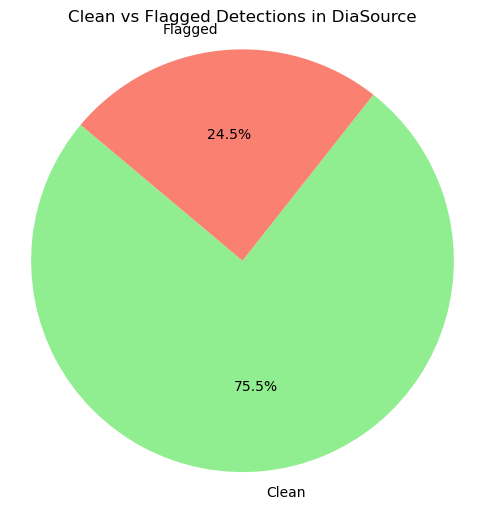

In [65]:
# Quantifying flux flags

# We dropped missing values, now filter out flag columns and zero checks for quality improvement
# DiaObject doesn't have flags like these, so we don't identify/quantify any here

# DiaSource
diasourcedf = diasourcedf[
    (~diasourcedf['psfFlux_flag']) &
    (~diasourcedf['psfFlux_flag_edge']) &
    (~diasourcedf['psfFlux_flag_noGoodPixels']) &
    (diasourcedf['psfFlux'] > 0)
]

# Object (g, r, i bands) 
objectGdf = objectGdf[
    (~objectGdf['g_psfFlux_flag']) &
    (objectGdf['g_psfFlux'] > 0)
]

objectRdf = objectRdf[
    (~objectRdf['r_psfFlux_flag']) &
    (objectRdf['r_psfFlux'] > 0)
]

objectIdf = objectIdf[
    (~objectIdf['i_psfFlux_flag']) &
    (objectIdf['i_psfFlux'] > 0)
]

# Pie Chart 

# DiaSource 

diasourcedf = pd.read_csv("diasource.csv")

diasourcedf['is_flagged'] = diasourcedf[
    ['psfFlux_flag', 'psfFlux_flag_edge', 'psfFlux_flag_noGoodPixels']
].astype(bool).any(axis=1)

diasourceflag_counts = diasourcedf['is_flagged'].value_counts()
print(diasourceflag_counts)

labels = ['Clean', 'Flagged']
sizes = [diasourceflag_counts[False], diasourceflag_counts[True]]
colors = ['lightgreen', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Clean vs Flagged Detections in DiaSource')
plt.axis('equal')  # circle
plt.show()

is_flagged
False    359298
True       3381
Name: count, dtype: int64


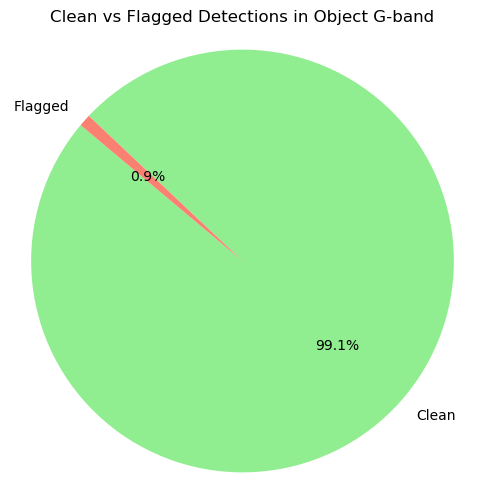

In [66]:
# Object G-band 
objectGdf = pd.read_csv("objectG.csv")
objectGdf['is_flagged'] = objectGdf['g_psfFlux_flag'].fillna(False).astype(bool)

objectGflag_counts = objectGdf['is_flagged'].value_counts()
print(objectGflag_counts)

labels = ['Clean', 'Flagged']
sizes = [objectGflag_counts[False], objectGflag_counts[True]]
colors = ['lightgreen', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Clean vs Flagged Detections in Object G-band')
plt.axis('equal')  
plt.show()

is_flagged
False    436580
True       3434
Name: count, dtype: int64


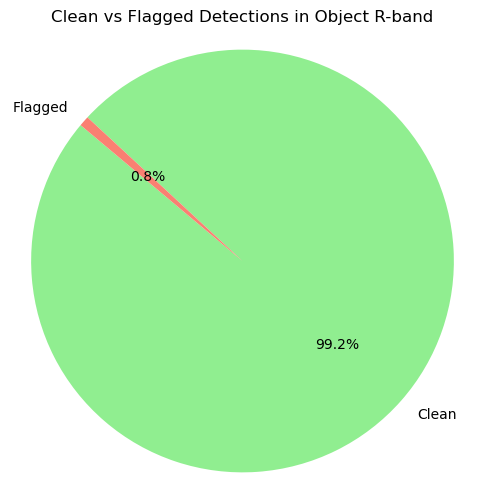

In [67]:
# Object R-band 
objectRdf = pd.read_csv("objectR.csv")
# flag indicator column
objectRdf['is_flagged'] = objectRdf['r_psfFlux_flag'].fillna(False).astype(bool)

objectRflag_counts = objectRdf['is_flagged'].value_counts()
print(objectRflag_counts)

labels = ['Clean', 'Flagged']
sizes = [objectRflag_counts[False], objectRflag_counts[True]]
colors = ['lightgreen', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Clean vs Flagged Detections in Object R-band')
plt.axis('equal')  
plt.show()

is_flagged
False    494665
True       3839
Name: count, dtype: int64


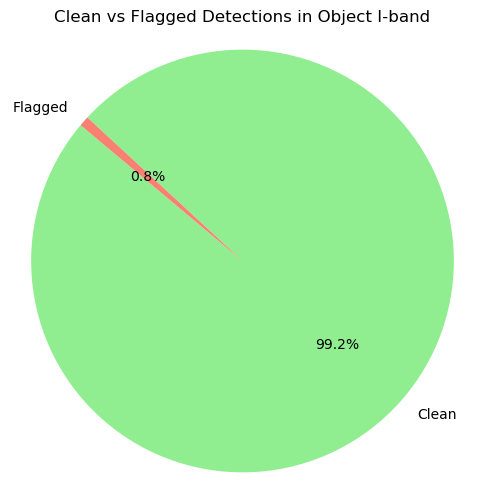

In [68]:
# Object I-band 
objectIdf = pd.read_csv("objectI.csv")
# flag indicator column
objectIdf['is_flagged'] = objectIdf['i_psfFlux_flag'].fillna(False).astype(bool)

objectIflag_counts = objectIdf['is_flagged'].value_counts()
print(objectIflag_counts)

labels = ['Clean', 'Flagged']
sizes = [objectIflag_counts[False], objectIflag_counts[True]]
colors = ['lightgreen', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Clean vs Flagged Detections in Object I-band')
plt.axis('equal')  
plt.show()

In [69]:
# Make csvs files, run once!

diasourcedf.to_csv("diasource.csv", index=False)
objectGdf.to_csv("objectG.csv", index=False)
objectRdf.to_csv("objectR.csv", index=False)
objectIdf.to_csv("objectI.csv", index=False)

**Band Comparison**

Variability and Color Analysis
1) ```gPSFluxSigma``` vs ```rPSFluxSigma``` - Compare blue vs red variability, helps separate RR Lyrae (high in g) from Cepheids (moderate in r)

In [70]:
# Merging all bands
diaobject_merged = diaobjectGdf[['diaObjectId', 'g_psfFluxSigma', 'g_psfFluxMean']].merge(
    diaobjectRdf[['diaObjectId', 'r_psfFluxSigma', 'r_psfFluxMean']], on='diaObjectId').merge(
    diaobjectIdf[['diaObjectId', 'i_psfFluxSigma', 'i_psfFluxMean']], on='diaObjectId')

diaobject_merged['g_r'] = diaobject_merged['g_psfFluxMean'] - diaobject_merged['r_psfFluxMean']
diaobject_merged['r_i'] = diaobject_merged['r_psfFluxMean'] - diaobject_merged['i_psfFluxMean']
diaobject_merged['g_i'] = diaobject_merged['g_psfFluxMean'] - diaobject_merged['i_psfFluxMean']

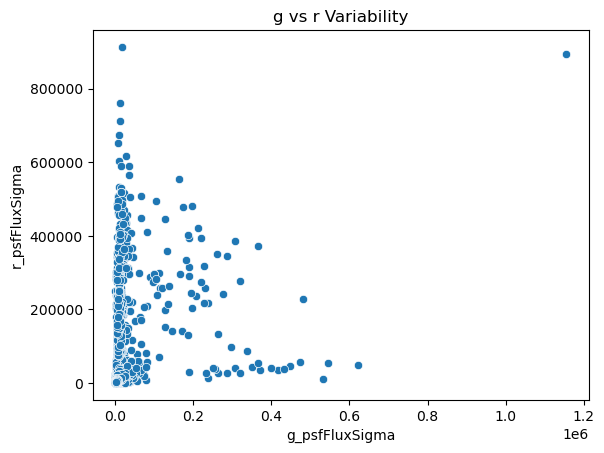

In [71]:
# gPSFluxSigma vs rPSFluxSigma

sns.scatterplot(data=diaobject_merged, x='g_psfFluxSigma', y='r_psfFluxSigma')
plt.xlabel('g_psfFluxSigma'); plt.ylabel('r_psfFluxSigma')
plt.title('g vs r Variability'); plt.show()

2) ```gPSFluxSigma vs iPSFluxSigma``` - Compare blue vs infrared variability, useful to isolate Miras (stronger variation in i) from RR Lyrae

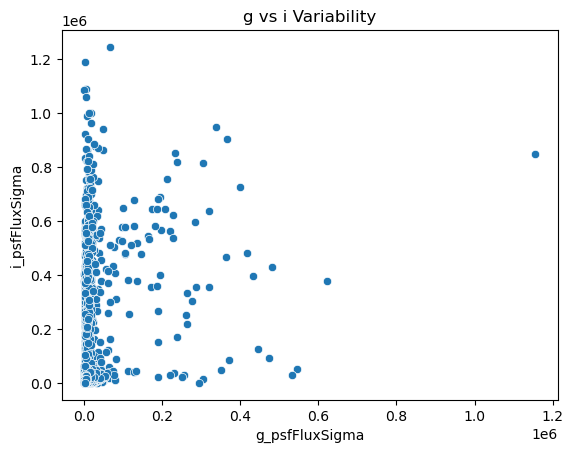

In [74]:
# gPSFluxSigma vs iPSFluxSigma
sns.scatterplot(data=diaobject_merged, x='g_psfFluxSigma', y='i_psfFluxSigma')
plt.xlabel('g_psfFluxSigma'); plt.ylabel('i_psfFluxSigma')
plt.title('g vs i Variability'); plt.show()

3) ```rPSFluxSigma``` vs ```iPSFluxSigma``` - Compare red vs redder variability, differentiates Cepheids (stronger in r) from Miras (stronger in i)

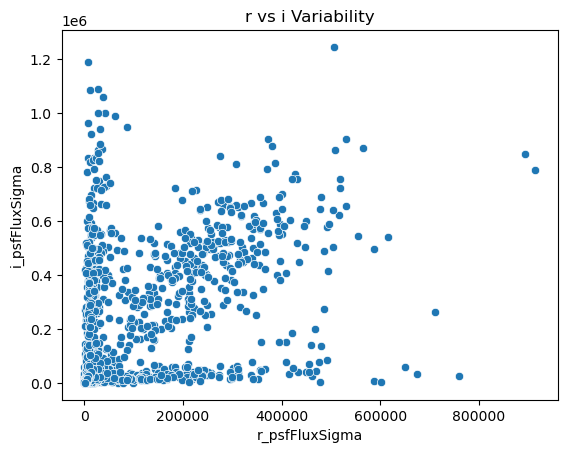

In [75]:
# rPSFluxSigma vs iPSFluxSigma
sns.scatterplot(data=diaobject_merged, x='r_psfFluxSigma', y='i_psfFluxSigma')
plt.xlabel('r_psfFluxSigma'); plt.ylabel('i_psfFluxSigma')
plt.title('r vs i Variability'); plt.show()

4) ```g - r``` vs ```gPSFluxSigma``` - Shows how blue-red color correlates with g-band variability, RR Lyrae are usually bluer, with higher variability

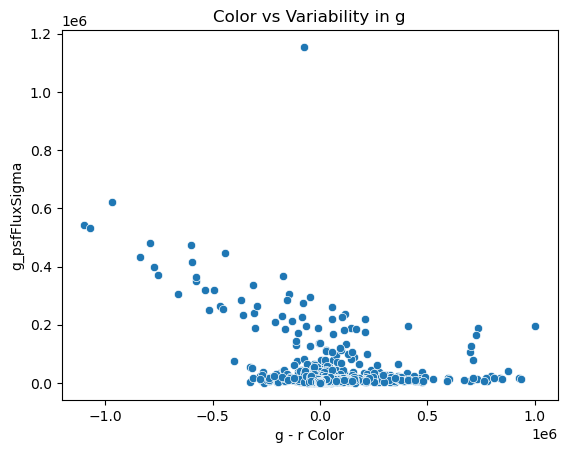

In [76]:
# g - r (x) vs gPSFluxSigma (y)
sns.scatterplot(data=diaobject_merged, x='g_r', y='g_psfFluxSigma')
plt.xlabel('g - r Color'); plt.ylabel('g_psfFluxSigma')
plt.title('Color vs Variability in g'); plt.show()

5) ```r - i vs iPSFluxSigma``` - Shows how red–infrared color tracks with i-band variability, great for flagging Miras, which are redder and vary more in i

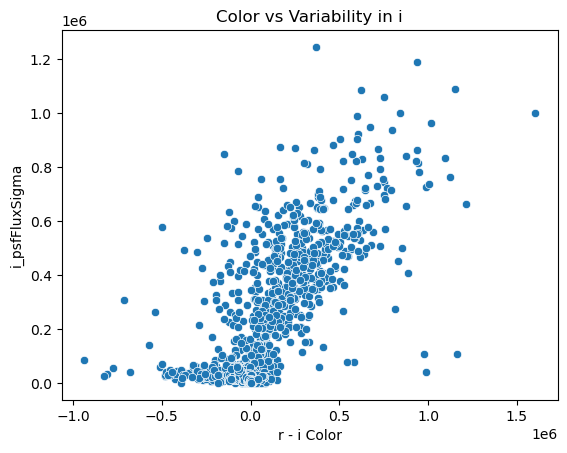

In [77]:
# r - i (x) vs iPSFluxSigma (y)
sns.scatterplot(data=diaobject_merged, x='r_i', y='i_psfFluxSigma')
plt.xlabel('r - i Color'); plt.ylabel('i_psfFluxSigma')
plt.title('Color vs Variability in i'); plt.show()

6) ```g - i``` vs ```rPSFluxSigma``` (the most informative band of all three) - Long baseline color, useful for separating cool vs hot variables, can highlight outliers or transition stars

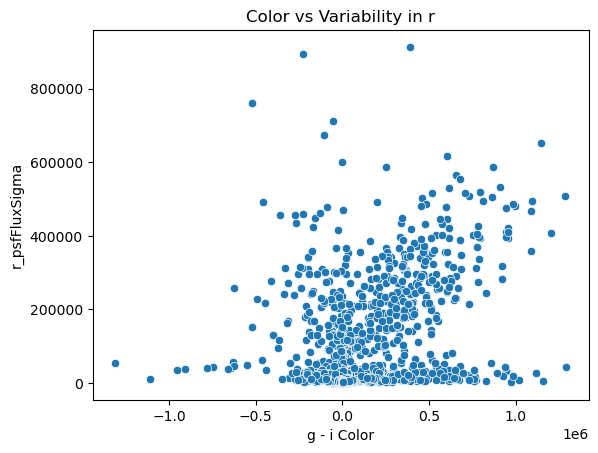

In [78]:
# g - i (x) vs rPSFluxSigma
sns.scatterplot(data=diaobject_merged, x='g_i', y='r_psfFluxSigma')
plt.xlabel('g - i Color'); plt.ylabel('r_psfFluxSigma')
plt.title('Color vs Variability in r'); plt.show()

7) Histograms of ```PSFluxSigma``` in Each Band - Helps visualize overall variability strength distribution by band

One histogram for each of:

a) ```gPSFluxSigma``` (std dev) vs number of star/detections (count)
b) ```rPSFluxSigma``` (std dev) vs number of star/detections (count)
c) ```iPSFluxSigma``` (std dev) vs number of star/detections (count)

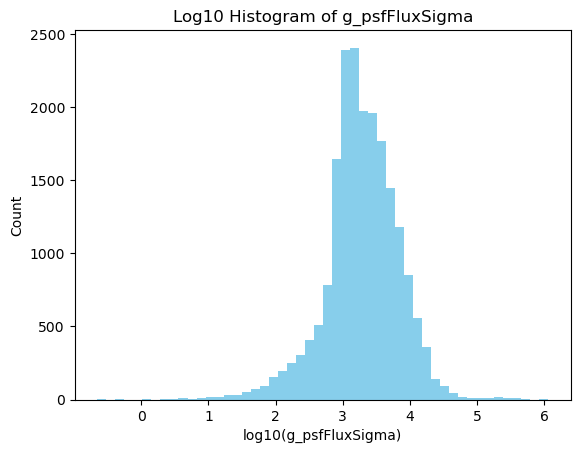

In [80]:
# gpsFluxSigma vs count
valid_fluxsigma = diaobject_merged['g_psfFluxSigma']
valid_fluxsigma = valid_fluxsigma[valid_fluxsigma > 0]

# Log-transform and plot
plt.hist(np.log10(valid_fluxsigma), bins=50, color='skyblue')
plt.title('Log10 Histogram of g_psfFluxSigma')
plt.xlabel('log10(g_psfFluxSigma)')
plt.ylabel('Count')
plt.show()

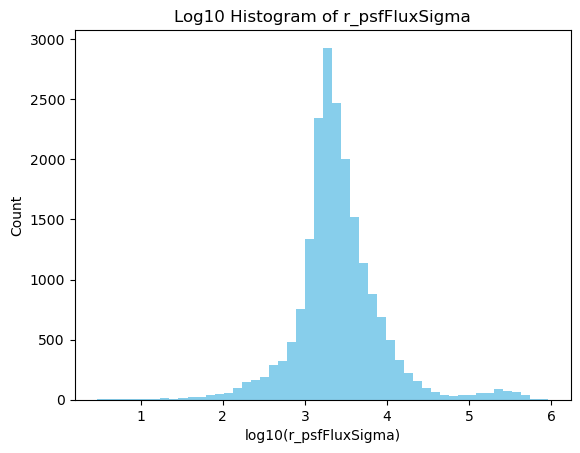

In [81]:
# rpsFluxSigma vs count
valid_fluxsigma = diaobject_merged['r_psfFluxSigma']
valid_fluxsigma = valid_fluxsigma[valid_fluxsigma > 0]

# Log-transform and plot
plt.hist(np.log10(valid_fluxsigma), bins=50, color='skyblue')
plt.title('Log10 Histogram of r_psfFluxSigma')
plt.xlabel('log10(r_psfFluxSigma)')
plt.ylabel('Count')
plt.show()

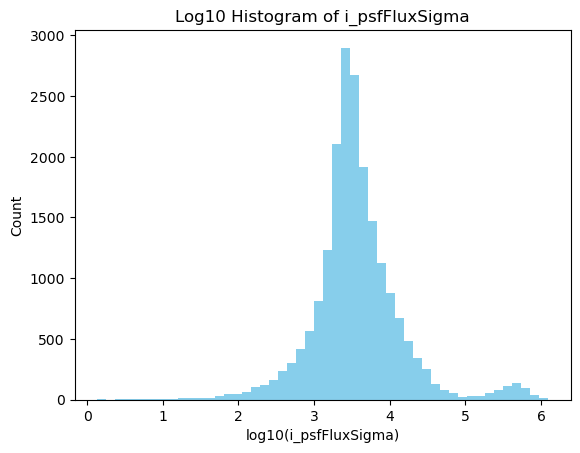

In [82]:
# ipsFluxSigma vs count
valid_fluxsigma = diaobject_merged['i_psfFluxSigma']
valid_fluxsigma = valid_fluxsigma[valid_fluxsigma > 0]

# Log-transform and plot
plt.hist(np.log10(valid_fluxsigma), bins=50, color='skyblue')
plt.title('Log10 Histogram of i_psfFluxSigma')
plt.xlabel('log10(i_psfFluxSigma)')
plt.ylabel('Count')
plt.show()

**Outlier Validation**

High variability metrics don’t always mean true variability. We:
1) Select stars with high Chi², MAD, Stetson J
2) Validate light curves for anomalies or bad data

#### **Findings**

1. **Flux Reliability Differs by Table Type**  
   - The **Object table**, which stores co-added and calibrated photometry, showed **>99% clean fluxes** in g-band based on `psfFlux_flag`. This confirms high reliability across all bands (g, r, i).
   - The **DiaSource table**, containing nightly detections, had **~75% clean fluxes** after filtering. About 25% were flagged due to saturation, edge effects, or bad pixels.

2. **Band-Specific Flagging Trends**  
   - Flux flags were applied per band (`g_psfFlux_flag`, `r_psfFlux_flag`, etc.), though specific per-band rates weren’t computed. g-band is typically more susceptible to atmospheric effects, possibly increasing its flag rate slightly.

3. **Use Case Implications**  
   - **DiaSource** is essential for variability analysis but noisier. Flag filtering is critical to avoid distortion in metrics like `psfFluxSigma`.
   - **Object** fluxes are stable and reliable, ideal for static analyses like color-magnitude diagrams and initial classification.

4. **Flux Distribution Behavior**  
   - Post-filtering histograms of `psfFluxSigma` reveal:
     - A peak at low variability (majority of stars),
     - A long right-tail of highly variable sources.
   - This pattern supports using `FluxSigma` to identify variable stars as statistical outliers.

---

#### **Summary**

Rubin DP1 data shows high-quality flux measurements:
- **Object table**: ~99% of entries are clean and photometrically reliable.
- **DiaSource table**: ~75% pass the flag filters, providing a large and usable dataset for variability science.
- The shape of the `psfFluxSigma` distribution supports the assumption that most stars are stable, with distinct high-variability outliers.

---

#### **Results**

These checks validate the Rubin pipeline’s flux integrity:
- **Object fluxes** are excellent for color and population studies.
- **DiaSource fluxes** support temporal variability analysis when properly filtered.
- Histogram tails and sigma comparisons offer a way to define thresholds for “variability,” helping to identify:
  - **RR Lyrae** (high g-band sigma),
  - **Cepheids** (moderate r-band sigma),
  - **Miras** (strong i-band sigma).

The results establish a strong foundation for classifying variable stars and setting up reliable feature engineering pipelines.